# A09 - Interpretabilidade e Visualizacao

Este notebook reutiliza o modelo treinado no **A08 - Transfer Learning** para
analisar o desempenho no conjunto de teste sem realizar novo treinamento.

**Escopo desta entrega:**
- gerar e organizar predicoes para analise;
- construir visualizacoes quantitativas do modelo;
- interpretar os padroes observados nas figuras;
- deixar secoes-template para os itens 3, 4 e 5 do artefato.

## Roteiro do notebook

1. Carregar os artefatos do A08 (`history.csv` e `best_model.keras`).
2. Reconstruir o mesmo split treino/validacao/teste do A08.
3. Gerar predicoes em validacao e teste.
4. Comparar dois thresholds: `0.5` e `threshold_f1` ajustado na validacao.
5. Produzir curvas de treino, matrizes de confusao e distribuicoes de probabilidade.
6. Registrar interpretacao textual obrigatoria apos cada bloco principal.

# Artefato A09 — Interpretabilidade e Visualização

Este notebook apresenta o Artefato A09, cujo objetivo é implementar **heatmaps** e **mapas de probabilidade** sobrepostos nas imagens ASTER originais, permitindo interpretar visualmente quais regiões espaciais e espectrais o modelo CNN utiliza para tomar decisões de classificação mineralógica no projeto SpectraAI.

A interpretabilidade de modelos de aprendizado profundo aplicados a dados de sensoriamento remoto é uma etapa fundamental para validar se as redes neurais estão aprendendo padrões geologicamente significativos, em vez de artefatos espúrios nos dados. Em contextos de exploração mineral, onde decisões baseadas em modelos podem direcionar campanhas de campo com custos elevados, é essencial que os geólogos e especialistas de domínio possam inspecionar visualmente as regiões da imagem que fundamentam cada predição.

O artefato está organizado nas seguintes etapas:

1. **Configuração do ambiente** — carregamento de dependências, modelos treinados e dados.
2. **Implementação de Grad-CAM** — cálculo dos mapas de ativação ponderados por gradientes a partir da última camada convolucional, gerando heatmaps que destacam regiões espaciais relevantes para cada predição.
3. **Composições RGB de falsa cor** — visualização das bandas ASTER em combinações RGB para contextualização geológica das amostras.
4. **Sobreposição de heatmaps nas imagens originais** — combinação dos mapas Grad-CAM com as composições de falsa cor das imagens ASTER, permitindo análise integrada.
5. **Mapas de probabilidade** — geração de mapas espaciais com as probabilidades de classificação por tile, sobrepostos nas imagens originais.
6. **Análise e interpretação** — discussão dos resultados à luz das hipóteses geológicas do projeto, avaliando se o modelo foca em regiões espectralmente relevantes para a identificação mineral.

In [3]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1) Configuração do ambiente

Esta seção configura o ambiente de execução, verifica dependências, carrega os modelos treinados nos artefatos anteriores e prepara os dados para as etapas de interpretabilidade. A lógica segue o mesmo padrão adotado nos artefatos A05 e A08, garantindo consistência metodológica ao longo do projeto.

O notebook detecta automaticamente a disponibilidade do TensorFlow. Caso esteja presente, as técnicas de Grad-CAM são executadas diretamente. Caso contrário, o notebook opera em modo de revisão, carregando artefatos previamente gerados.

In [1]:
import importlib.util
import sys

PYTHON_VERSION = sys.version_info[:3]
REQUIRED_PACKAGES = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'sklearn': 'scikit-learn',
    'tensorflow': 'tensorflow',
}

if PYTHON_VERSION < (3, 10) or PYTHON_VERSION >= (3, 13):
    raise RuntimeError(
        'Este notebook foi preparado para rodar com TensorFlow em Python 3.10, 3.11 ou 3.12. '
        f'Ambiente atual: {sys.version.split()[0]}. '
        'Use Google Colab ou um ambiente local compativel.'
    )

missing = [
    pkg_name
    for module_name, pkg_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]
if missing:
    raise RuntimeError(
        'Pacotes ausentes para executar o notebook: ' + ', '.join(missing) + '. '
        'Instale as dependencias do projeto antes de prosseguir.'
    )

In [2]:
import importlib.util
import subprocess
import sys

PYTHON_VERSION = sys.version_info[:3]
REQUIRED_PACKAGES = {
    "sklearn": "scikit-learn",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
}

if PYTHON_VERSION < (3, 10) or PYTHON_VERSION >= (3, 13):
    raise RuntimeError(
        "Este notebook foi preparado para rodar com TensorFlow em Python 3.10, 3.11 ou 3.12. "
        f"Ambiente atual: {sys.version.split()[0]}. "
        "Use Google Colab ou um ambiente local com Python 3.11/3.12."
    )

REQUIRED_PACKAGES["tensorflow"] = "tensorflow"

missing = [
    pip_name
    for module_name, pip_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

print("Dependências OK.")

Dependências OK.


In [3]:
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import Markdown, display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from tensorflow import keras


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / 'src').exists():
        return cwd
    for parent in [cwd, *cwd.parents]:
        if (parent / 'src').exists():
            return parent
    raise FileNotFoundError('Nao foi possivel localizar a raiz do projeto.')


PROJECT_ROOT = resolve_project_root()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from analise_visual.framework_visualizacao import (
    plot_confusion_matrix,
    plot_probability_distributions,
)
from inference import collect_binary_predictions
from models.cnn_data_prep import prepare_grouped_cnn_splits
from models.cnn_tf_data_pipeline import build_train_val_test_tf_data
from utils.metrics import select_threshold_by_f1

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_CSV = PROJECT_ROOT / 'data' / 'pixels_dataset.csv'
EXTRACTED_CODES_JSON = PROJECT_ROOT / 'data' / 'extracted_codes.json'
A08_OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'a08_transfer_learning'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'a09_interpretabilidade_visualizacao'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HISTORY_PATH = A08_OUTPUT_DIR / 'history.csv'
MODEL_PATH = A08_OUTPUT_DIR / 'best_model.keras'

TEST_SIZE = 0.20
VAL_SIZE = 0.20
BATCH_SIZE = 8
TARGET_SIZE = (160, 160)
NORMALIZATION = 'zscore'
CLASS_NAMES = ('Negativo', 'Positivo')


def build_unique_sample_ids(image_ids):
    return [f'{str(image_id)}__tile_{idx:04d}' for idx, image_id in enumerate(image_ids)]


def compute_binary_metrics(y_true, y_prob, threshold, threshold_name):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        'threshold_name': threshold_name,
        'threshold': float(threshold),
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'pr_auc': average_precision_score(y_true, y_prob),
    }

In [4]:
assert DATASET_CSV.exists(), f'Arquivo nao encontrado: {DATASET_CSV}'
assert EXTRACTED_CODES_JSON.exists(), f'Arquivo nao encontrado: {EXTRACTED_CODES_JSON}'
assert HISTORY_PATH.exists(), f'Arquivo nao encontrado: {HISTORY_PATH}'
assert MODEL_PATH.exists(), f'Arquivo nao encontrado: {MODEL_PATH}'

history_df = pd.read_csv(HISTORY_PATH)
phase1_epochs = int((history_df['phase'] == 'head_training').sum())
best_epoch_idx = int(history_df['val_loss'].idxmin())
best_epoch_num = best_epoch_idx + 1
best_epoch_row = history_df.iloc[best_epoch_idx]

artifact_overview = pd.DataFrame(
    [
        {'artefato': 'Historico consolidado do treino', 'caminho': str(HISTORY_PATH)},
        {'artefato': 'Melhor modelo salvo no A08', 'caminho': str(MODEL_PATH)},
        {'artefato': 'Saida do A09', 'caminho': str(OUTPUT_DIR)},
    ]
)

display(artifact_overview)
display(history_df.head())
print(f'Melhor epoca por val_loss: {best_epoch_num}')
print(f'Fase 1 (head training): {phase1_epochs} epocas')
print(f'Fase 2 (fine-tuning): {len(history_df) - phase1_epochs} epocas')

AssertionError: Arquivo nao encontrado: /Users/pedroauler/Developer/inteli/inteliM9/g01/outputs/a08_transfer_learning/history.csv

In [6]:
df = pd.read_csv(DATASET_CSV)

split_data = prepare_grouped_cnn_splits(
    df,
    extracted_codes_path=EXTRACTED_CODES_JSON,
    data_format='channels_last',
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    seed=SEED,
)

tf_data = build_train_val_test_tf_data(
    split_data['X_train'],
    split_data['y_train'],
    split_data['X_val'],
    split_data['y_val'],
    split_data['X_test'],
    split_data['y_test'],
    batch_size=BATCH_SIZE,
    normalization=NORMALIZATION,
    resize_to=TARGET_SIZE,
    data_format='channels_last',
    target_channels=split_data['shape_info']['n_channels'],
    augment_train=True,
    seed=SEED,
)

model = keras.models.load_model(MODEL_PATH)

split_overview = pd.DataFrame(
    [
        {'split': 'train', 'samples': len(split_data['y_train']), 'classes': dict(zip(*np.unique(split_data['y_train'], return_counts=True)))},
        {'split': 'val', 'samples': len(split_data['y_val']), 'classes': dict(zip(*np.unique(split_data['y_val'], return_counts=True)))},
        {'split': 'test', 'samples': len(split_data['y_test']), 'classes': dict(zip(*np.unique(split_data['y_test'], return_counts=True)))},
    ]
)

display(split_overview)
print(f"Shape de entrada do modelo: {tf_data['train_meta']['input_shape']}")
print(f'Modelo carregado de: {MODEL_PATH}')

,split,samples,classes
0,train,177,"{0: 107, 1: 70}"
1,val,59,"{0: 36, 1: 23}"
2,test,59,"{0: 36, 1: 23}"


Shape de entrada do modelo: (160, 160, 9)
Modelo carregado de: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a08_transfer_learning/best_model.keras


## Item 1 - Geracao de predicoes e outputs do modelo

Embora o foco principal deste notebook seja o **item 2**, esta secao gera as
predicoes que servem de base para as visualizacoes quantitativas e para as
etapas seguintes de interpretabilidade.

In [7]:
val_sample_ids = build_unique_sample_ids(split_data['image_ids_val'])
test_sample_ids = build_unique_sample_ids(split_data['image_ids_test'])

val_predictions = collect_binary_predictions(
    model,
    tf_data['val_ds'],
    sample_ids=val_sample_ids,
)
val_predictions['image_id'] = split_data['image_ids_val']

threshold_f1 = select_threshold_by_f1(
    val_predictions['y_true'].to_numpy(),
    val_predictions['prob_pos'].to_numpy(),
    default_threshold=0.5,
)

test_predictions = collect_binary_predictions(
    model,
    tf_data['test_ds'],
    sample_ids=test_sample_ids,
)
test_predictions['image_id'] = split_data['image_ids_test']
test_predictions['pred_05'] = (test_predictions['prob_pos'] >= 0.5).astype(int)
test_predictions['pred_f1'] = (test_predictions['prob_pos'] >= threshold_f1).astype(int)
test_predictions['erro_05'] = (test_predictions['pred_05'] != test_predictions['y_true']).astype(int)
test_predictions['erro_f1'] = (test_predictions['pred_f1'] != test_predictions['y_true']).astype(int)

test_predictions = test_predictions[
    ['sample_id', 'image_id', 'y_true', 'prob_neg', 'prob_pos', 'pred_05', 'pred_f1', 'erro_05', 'erro_f1']
].copy()

test_predictions_path = OUTPUT_DIR / 'test_predictions.csv'
test_predictions.to_csv(test_predictions_path, index=False)

display(test_predictions.head(10))
print(f'threshold_f1 ajustado na validacao: {threshold_f1:.4f}')
print(f'Predicoes salvas em: {test_predictions_path}')
print(f'Numero de amostras no teste: {len(test_predictions)}')

,sample_id,image_id,y_true,prob_neg,prob_pos,pred_05,pred_f1,erro_05,erro_f1
0,23273__tile_0000,23273,0,0.757693,0.242307,0,0,0,0
1,23350__tile_0001,23350,0,0.993418,0.006582,0,0,0,0
2,23576B__tile_0002,23576B,0,0.886396,0.113604,0,0,0,0
3,23577__tile_0003,23577,0,0.497648,0.502352,1,1,1,1
4,25636__tile_0004,25636,1,0.590064,0.409936,0,1,1,0
5,31712__tile_0005,31712,1,0.355689,0.644311,1,1,0,0
6,31771__tile_0006,31771,1,0.256318,0.743682,1,1,0,0
7,31932__tile_0007,31932,1,0.376221,0.623779,1,1,0,0
8,31945__tile_0008,31945,1,0.403968,0.596032,1,1,0,0
9,31951__tile_0009,31951,1,0.284557,0.715443,1,1,0,0


threshold_f1 ajustado na validacao: 0.3302
Predicoes salvas em: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a09_interpretabilidade_visualizacao/test_predictions.csv
Numero de amostras no teste: 59


## Item 2.1 - Curvas de treino (loss e accuracy)

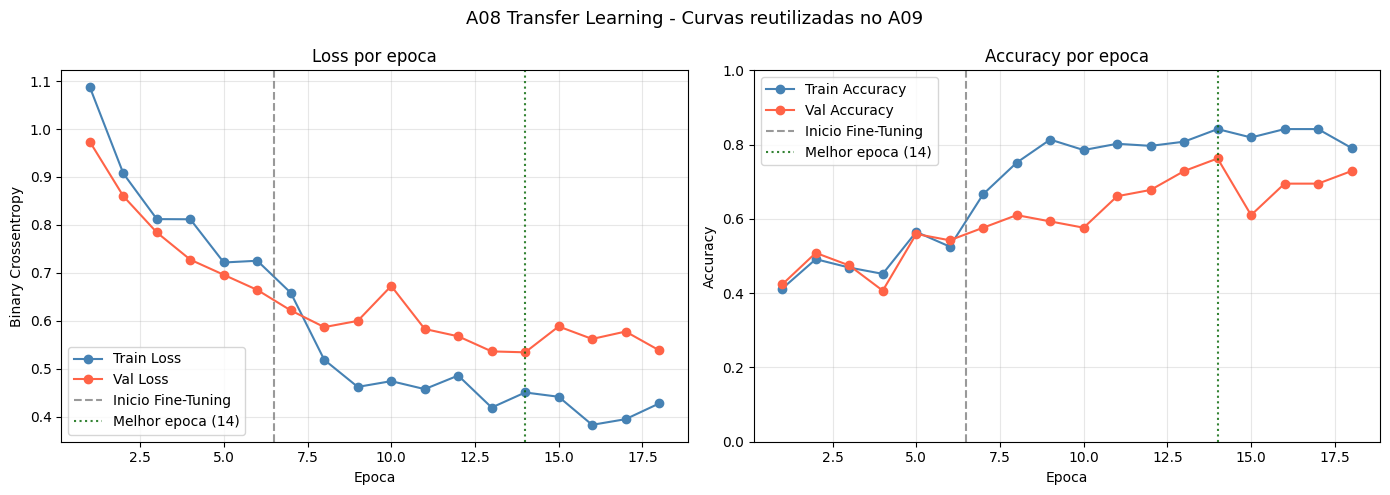

,melhor_epoca,melhor_fase,val_loss_min,val_accuracy_na_melhor_epoca,gap_accuracy_final
0,14,fine_tuning,0.534,0.7627,0.0621


Grafico salvo em: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a09_interpretabilidade_visualizacao/training_curves_from_history.png


In [8]:
epochs = np.arange(1, len(history_df) + 1)
curves_path = OUTPUT_DIR / 'training_curves_from_history.png'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history_df['loss'], label='Train Loss', marker='o', color='steelblue')
axes[0].plot(epochs, history_df['val_loss'], label='Val Loss', marker='o', color='tomato')
axes[0].axvline(phase1_epochs + 0.5, color='gray', linestyle='--', alpha=0.8, label='Inicio Fine-Tuning')
axes[0].axvline(best_epoch_num, color='darkgreen', linestyle=':', alpha=0.8, label=f'Melhor epoca ({best_epoch_num})')
axes[0].set_title('Loss por epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, history_df['accuracy'], label='Train Accuracy', marker='o', color='steelblue')
axes[1].plot(epochs, history_df['val_accuracy'], label='Val Accuracy', marker='o', color='tomato')
axes[1].axvline(phase1_epochs + 0.5, color='gray', linestyle='--', alpha=0.8, label='Inicio Fine-Tuning')
axes[1].axvline(best_epoch_num, color='darkgreen', linestyle=':', alpha=0.8, label=f'Melhor epoca ({best_epoch_num})')
axes[1].set_title('Accuracy por epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.suptitle('A08 Transfer Learning - Curvas reutilizadas no A09', fontsize=13)
fig.tight_layout()
fig.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()

curve_summary = pd.DataFrame(
    [
        {
            'melhor_epoca': best_epoch_num,
            'melhor_fase': best_epoch_row['phase'],
            'val_loss_min': round(float(best_epoch_row['val_loss']), 4),
            'val_accuracy_na_melhor_epoca': round(float(best_epoch_row['val_accuracy']), 4),
            'gap_accuracy_final': round(float(history_df.iloc[-1]['accuracy'] - history_df.iloc[-1]['val_accuracy']), 4),
        }
    ]
)

display(curve_summary)
print(f'Grafico salvo em: {curves_path}')

In [9]:
final_acc_gap = float(history_df.iloc[-1]['accuracy'] - history_df.iloc[-1]['val_accuracy'])
curve_reading = 'indica overfitting moderado ao final do treino' if final_acc_gap > 0.08 else 'permanece controlado ao final do treino'

curve_text = f'''    ### Interpretacao das curvas

As curvas mostram a transicao entre **head training** e **fine-tuning** sem necessidade de retreinar o modelo no A09.
A melhor epoca segundo `val_loss` ocorreu na **epoca {best_epoch_num}**, ja durante a fase **{best_epoch_row["phase"]}**, com `val_loss={best_epoch_row["val_loss"]:.4f}` e `val_accuracy={best_epoch_row["val_accuracy"]:.4f}`.

O gap final entre treino e validacao em acuracia foi de **{final_acc_gap:.4f}**, o que {curve_reading}. Em termos praticos, isso sugere que o modelo aprendeu um padrao util, mas que a generalizacao precisa ser lida em conjunto com as predicoes de validacao e teste, e nao apenas pelas metricas de treino.
'''

display(Markdown(curve_text))

    ### Interpretacao das curvas

As curvas mostram a transicao entre **head training** e **fine-tuning** sem necessidade de retreinar o modelo no A09.
A melhor epoca segundo `val_loss` ocorreu na **epoca 14**, ja durante a fase **fine_tuning**, com `val_loss=0.5340` e `val_accuracy=0.7627`.

O gap final entre treino e validacao em acuracia foi de **0.0621**, o que permanece controlado ao final do treino. Em termos praticos, isso sugere que o modelo aprendeu um padrao util, mas que a generalizacao precisa ser lida em conjunto com as predicoes de validacao e teste, e nao apenas pelas metricas de treino.


## Item 2.2 a 2.4 - Thresholds, matrizes de confusao e metricas por threshold

A partir das probabilidades do conjunto de teste, comparamos:
- `threshold=0.5` como referencia padrao;
- `threshold_f1` ajustado no conjunto de validacao para maximizar F1.

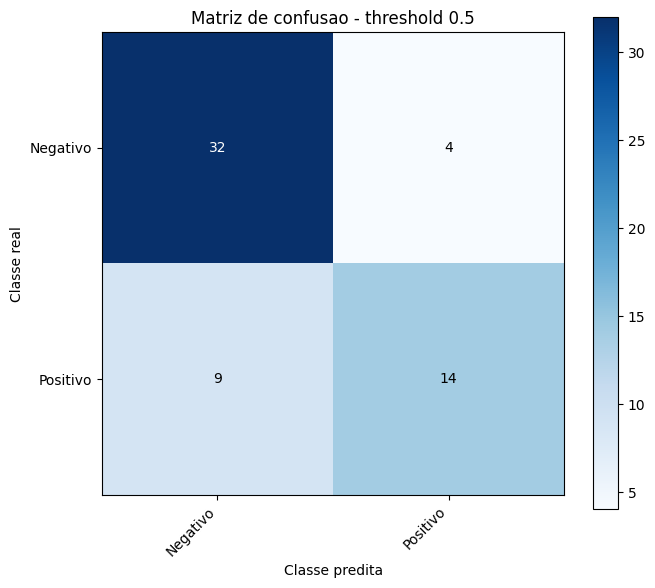

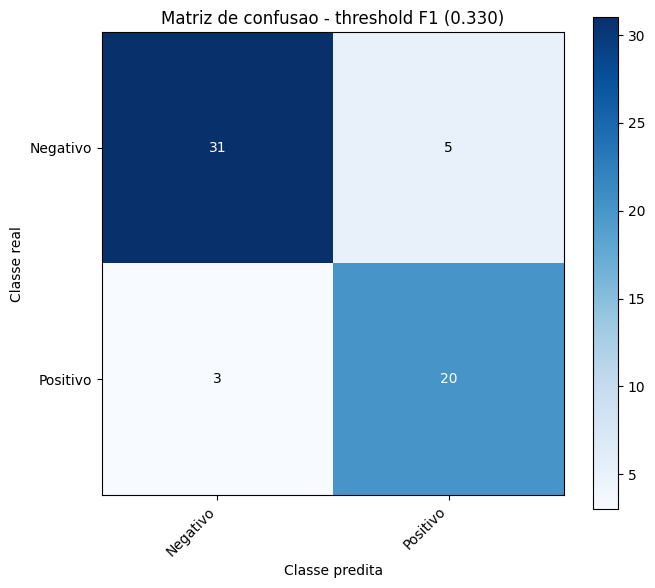

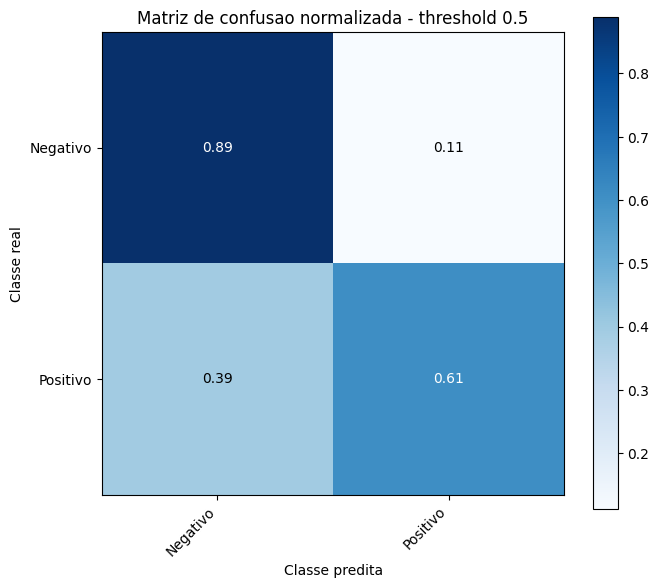

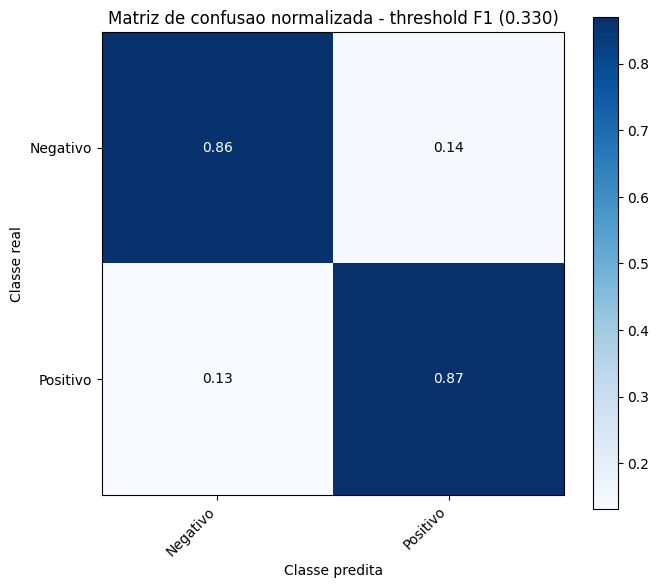

,threshold_name,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,threshold_0.5,0.5000,0.7797,0.7488,0.7778,0.6087,0.6829,0.9203,0.8989
1,threshold_f1,0.3302,0.8644,0.8653,0.8000,0.8696,0.8333,0.9203,0.8989


Metricas salvas em: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a09_interpretabilidade_visualizacao/test_metrics_comparison.csv


In [10]:
y_true_test = test_predictions['y_true'].to_numpy().astype(int)
y_prob_test = test_predictions['prob_pos'].to_numpy(dtype=float)

y_pred_05 = test_predictions['pred_05'].to_numpy().astype(int)
y_pred_f1 = test_predictions['pred_f1'].to_numpy().astype(int)

cm_05 = confusion_matrix(y_true_test, y_pred_05, labels=[0, 1])
cm_f1 = confusion_matrix(y_true_test, y_pred_f1, labels=[0, 1])

plot_confusion_matrix(
    cm_05,
    class_names=CLASS_NAMES,
    normalize=False,
    title='Matriz de confusao - threshold 0.5',
    save_path=OUTPUT_DIR / 'confusion_matrix_threshold_05.png',
    show=True,
)
plot_confusion_matrix(
    cm_f1,
    class_names=CLASS_NAMES,
    normalize=False,
    title=f'Matriz de confusao - threshold F1 ({threshold_f1:.3f})',
    save_path=OUTPUT_DIR / 'confusion_matrix_threshold_f1.png',
    show=True,
)
plot_confusion_matrix(
    cm_05,
    class_names=CLASS_NAMES,
    normalize=True,
    title='Matriz de confusao normalizada - threshold 0.5',
    save_path=OUTPUT_DIR / 'confusion_matrix_norm_threshold_05.png',
    show=True,
)
plot_confusion_matrix(
    cm_f1,
    class_names=CLASS_NAMES,
    normalize=True,
    title=f'Matriz de confusao normalizada - threshold F1 ({threshold_f1:.3f})',
    save_path=OUTPUT_DIR / 'confusion_matrix_norm_threshold_f1.png',
    show=True,
)

metrics_df = pd.DataFrame(
    [
        compute_binary_metrics(y_true_test, y_prob_test, 0.5, 'threshold_0.5'),
        compute_binary_metrics(y_true_test, y_prob_test, threshold_f1, 'threshold_f1'),
    ]
)
metrics_df = metrics_df.round(4)
metrics_path = OUTPUT_DIR / 'test_metrics_comparison.csv'
metrics_df.to_csv(metrics_path, index=False)

display(metrics_df)
print(f'Metricas salvas em: {metrics_path}')

In [11]:
tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()
tn_f1, fp_f1, fn_f1, tp_f1 = cm_f1.ravel()

threshold_direction = 'mais conservador' if threshold_f1 > 0.5 else 'mais sensivel' if threshold_f1 < 0.5 else 'equivalente ao padrao'

matrix_text = f'''    ### Interpretacao das matrizes de confusao

Com `threshold=0.5`, o modelo obteve **TN={tn_05}**, **FP={fp_05}**, **FN={fn_05}** e **TP={tp_05}**. Ja com `threshold_f1={threshold_f1:.4f}`, os valores passaram para **TN={tn_f1}**, **FP={fp_f1}**, **FN={fn_f1}** e **TP={tp_f1}**.

Como o `threshold_f1` ficou **{threshold_direction}** em relacao ao corte padrao de 0.5, a comparacao ajuda a mostrar o trade-off entre **precision** e **recall**. Em prospeccao mineral, essa leitura e importante porque reduzir falsos negativos evita perder areas potencialmente promissoras, enquanto reduzir falsos positivos evita priorizar locais com menor chance real de interesse.
'''

display(Markdown(matrix_text))

    ### Interpretacao das matrizes de confusao

Com `threshold=0.5`, o modelo obteve **TN=32**, **FP=4**, **FN=9** e **TP=14**. Ja com `threshold_f1=0.3302`, os valores passaram para **TN=31**, **FP=5**, **FN=3** e **TP=20**.

Como o `threshold_f1` ficou **mais sensivel** em relacao ao corte padrao de 0.5, a comparacao ajuda a mostrar o trade-off entre **precision** e **recall**. Em prospeccao mineral, essa leitura e importante porque reduzir falsos negativos evita perder areas potencialmente promissoras, enquanto reduzir falsos positivos evita priorizar locais com menor chance real de interesse.


## Item 2.5 - Distribuicoes de probabilidade por classe

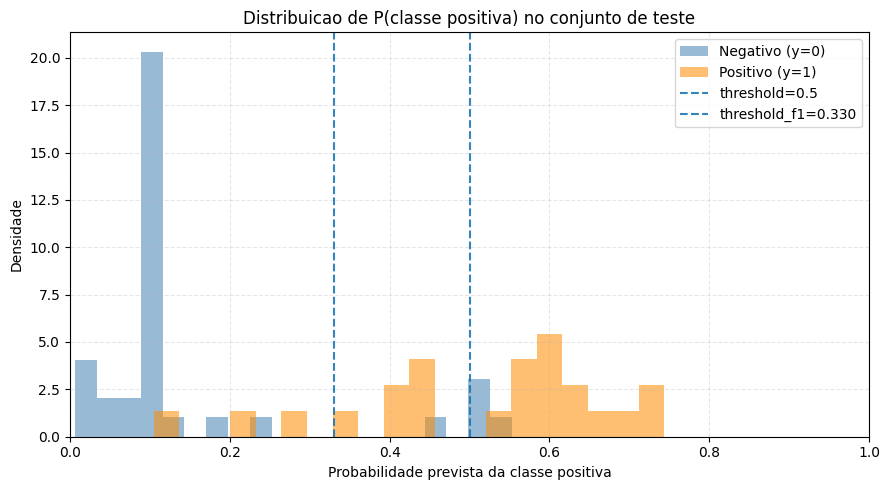

,count,mean,median,min,max
y_true,,,,,
Negativo,36,0.1527,0.105,0.0066,0.5532
Positivo,23,0.5118,0.572,0.1050,0.7437


Grafico salvo em: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a09_interpretabilidade_visualizacao/probability_distributions.png


In [12]:
plot_probability_distributions(
    y_true=y_true_test,
    y_score=y_prob_test,
    thresholds={
        'threshold=0.5': 0.5,
        f'threshold_f1={threshold_f1:.3f}': float(threshold_f1),
    },
    class_names=CLASS_NAMES,
    title='Distribuicao de P(classe positiva) no conjunto de teste',
    save_path=OUTPUT_DIR / 'probability_distributions.png',
    show=True,
)

probability_summary = (
    test_predictions.groupby('y_true')['prob_pos']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .rename(index={0: CLASS_NAMES[0], 1: CLASS_NAMES[1]})
    .round(4)
)

display(probability_summary)
print(f"Grafico salvo em: {OUTPUT_DIR / 'probability_distributions.png'}")

In [13]:
neg_mean = float(test_predictions.loc[test_predictions['y_true'] == 0, 'prob_pos'].mean())
pos_mean = float(test_predictions.loc[test_predictions['y_true'] == 1, 'prob_pos'].mean())
neg_above_05 = float((test_predictions.loc[test_predictions['y_true'] == 0, 'prob_pos'] >= 0.5).mean())
pos_above_05 = float((test_predictions.loc[test_predictions['y_true'] == 1, 'prob_pos'] >= 0.5).mean())

prob_text = f'''    ### Interpretacao das distribuicoes

As distribuicoes de `P(positivo)` mostram se o modelo separa bem as duas classes no espaco probabilistico. No conjunto de teste, a media da classe negativa foi **{neg_mean:.4f}**, enquanto a media da classe positiva foi **{pos_mean:.4f}**.

Quando a sobreposicao entre os histogramas aumenta, o modelo tende a produzir casos ambiguos proximos do threshold. Aqui, a proporcao de negativos acima de `0.5` foi **{neg_above_05:.2%}**, enquanto a proporcao de positivos acima de `0.5` foi **{pos_above_05:.2%}**. Isso ajuda a entender se o erro vem de um threshold mal posicionado ou de uma separacao probabilistica ainda limitada entre as classes.
'''

display(Markdown(prob_text))

    ### Interpretacao das distribuicoes

As distribuicoes de `P(positivo)` mostram se o modelo separa bem as duas classes no espaco probabilistico. No conjunto de teste, a media da classe negativa foi **0.1527**, enquanto a media da classe positiva foi **0.5118**.

Quando a sobreposicao entre os histogramas aumenta, o modelo tende a produzir casos ambiguos proximos do threshold. Aqui, a proporcao de negativos acima de `0.5` foi **11.11%**, enquanto a proporcao de positivos acima de `0.5` foi **60.87%**. Isso ajuda a entender se o erro vem de um threshold mal posicionado ou de uma separacao probabilistica ainda limitada entre as classes.


## Item 2.6 e 2.7 - Tabela-resumo e interpretacao critica final

In [14]:
uncertain_cases = test_predictions.assign(
    distancia_05=(test_predictions['prob_pos'] - 0.5).abs(),
    distancia_f1=(test_predictions['prob_pos'] - threshold_f1).abs(),
).sort_values('distancia_f1').head(10)

display(uncertain_cases)

,sample_id,image_id,y_true,prob_neg,prob_pos,pred_05,pred_f1,erro_05,erro_f1,distancia_05,distancia_f1
44,56476__tile_0044,56476,1,0.661904,0.338096,0,1,1,0,0.161904,0.007877
28,43257__tile_0028,43257,1,0.727656,0.272344,0,0,1,1,0.227656,0.057875
4,25636__tile_0004,25636,1,0.590064,0.409936,0,1,1,0,0.090064,0.079717
0,23273__tile_0000,23273,0,0.757693,0.242307,0,0,0,0,0.257693,0.087912
19,32471__tile_0019,32471,1,0.577344,0.422656,0,1,1,0,0.077344,0.092437
11,31983__tile_0011,31983,1,0.572764,0.427236,0,1,1,0,0.072764,0.097017
46,56481__tile_0046,56481,1,0.566019,0.433981,0,1,1,0,0.066019,0.103762
47,56496__tile_0047,56496,1,0.563887,0.436113,0,1,1,0,0.063887,0.105894
48,56499__tile_0048,56499,1,0.794113,0.205887,0,0,1,1,0.294113,0.124332
27,36699__tile_0027,36699,0,0.537779,0.462221,0,1,0,1,0.037779,0.132002


In [15]:
best_threshold_row = metrics_df.sort_values(['f1', 'recall', 'precision'], ascending=False).iloc[0]

final_text = f'''    ### Leitura critica consolidada

Entre os dois thresholds comparados, o melhor compromisso quantitativo no teste foi obtido por **{best_threshold_row['threshold_name']}**, com `F1={best_threshold_row['f1']:.4f}`, `recall={best_threshold_row['recall']:.4f}` e `precision={best_threshold_row['precision']:.4f}`.

A comparacao mostra que o modelo do A08 nao deve ser avaliado apenas por uma unica metrica agregada. As curvas de treino ajudam a verificar estabilidade, as matrizes de confusao explicam o tipo de erro dominante e as distribuicoes de probabilidade mostram se o threshold esta alinhado ao comportamento real do classificador.

No contexto de apoio a decisao em prospeccao, a implicacao pratica do trade-off e direta: um threshold mais baixo tende a aumentar a recuperacao de casos positivos reais, mas pode elevar o numero de falsos alarmes; um threshold mais alto reduz falsos positivos, mas aumenta o risco de deixar passar areas potencialmente relevantes. Por isso, o threshold final deve ser escolhido em funcao do custo relativo entre **FP** e **FN** na operacao.
'''

display(Markdown(final_text))

    ### Leitura critica consolidada

Entre os dois thresholds comparados, o melhor compromisso quantitativo no teste foi obtido por **threshold_f1**, com `F1=0.8333`, `recall=0.8696` e `precision=0.8000`.

A comparacao mostra que o modelo do A08 nao deve ser avaliado apenas por uma unica metrica agregada. As curvas de treino ajudam a verificar estabilidade, as matrizes de confusao explicam o tipo de erro dominante e as distribuicoes de probabilidade mostram se o threshold esta alinhado ao comportamento real do classificador.

No contexto de apoio a decisao em prospeccao, a implicacao pratica do trade-off e direta: um threshold mais baixo tende a aumentar a recuperacao de casos positivos reais, mas pode elevar o numero de falsos alarmes; um threshold mais alto reduz falsos positivos, mas aumenta o risco de deixar passar areas potencialmente relevantes. Por isso, o threshold final deve ser escolhido em funcao do custo relativo entre **FP** e **FN** na operacao.


## Item 3 - Visualizacoes espaciais ou mapas de predicao

**Template para continuidade do grupo:**

- reutilizar `test_predictions.csv` como base tabular;
- associar cada `sample_id` ou `image_id` as coordenadas correspondentes do tile;
- gerar heatmaps, sobreposicoes ou mapas geoespaciais quando a geometria estiver disponivel;
- interpretar concentracoes de acertos e erros no espaco.

In [2]:
import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except ImportError:
    sns = None

try:
    from IPython.display import Markdown, display
except ImportError:
    def display(obj):
        print(obj)
    def Markdown(text):
        return text


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src").exists():
        return cwd
    for parent in [cwd, *cwd.parents]:
        if (parent / "src").exists():
            return parent
    raise FileNotFoundError("Não foi possível localizar a raiz do projeto.")


PROJECT_ROOT = resolve_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from models.cnn_data_prep import prepare_grouped_cnn_splits

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_CSV = PROJECT_ROOT / "data" / "pixels_dataset.csv"
EXTRACTED_CODES_JSON = PROJECT_ROOT / "data" / "extracted_codes.json"
TRAINED_MODELS_DIR = PROJECT_ROOT / "outputs" / "trained_models"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "a09_interpretabilidade_visualizacao"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (12, 8)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

print(f"Raiz do projeto: {PROJECT_ROOT}")
print(f"Diretório de saída: {OUTPUT_DIR}")

Raiz do projeto: /Users/mateus/Projetos/Academico/Inteli/g01
Diretório de saída: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a09_interpretabilidade_visualizacao


### 1.1) Carregamento dos dados e modelo treinado

Carregamos o dataset e preparamos os splits de treino/validação/teste com o mesmo protocolo dos artefatos anteriores, garantindo que a avaliação de interpretabilidade seja feita sobre dados que o modelo não viu durante o treinamento.

In [3]:
assert DATASET_CSV.exists(), f"Arquivo não encontrado: {DATASET_CSV}"
assert EXTRACTED_CODES_JSON.exists(), f"Arquivo não encontrado: {EXTRACTED_CODES_JSON}"

TEST_SIZE = 0.15
VAL_SIZE = 0.15

df = pd.read_csv(DATASET_CSV)

split_data = prepare_grouped_cnn_splits(
    df,
    extracted_codes_path=EXTRACTED_CODES_JSON,
    data_format="channels_last",
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    seed=SEED,
)

X_test = split_data["X_test"]
y_test = split_data["y_test"]

# Labels binários: 0 = negativo, 1 = positivo (extracted_codes.json)
class_names = ["Negativo", "Positivo"]
n_classes = len(class_names)

print(f"Shape do conjunto de teste: {X_test.shape}")
print(f"Classes: {class_names}")
print(f"Distribuição no teste: {np.bincount(y_test)}")

Shape do conjunto de teste: (45, 128, 128, 9)
Classes: ['Negativo', 'Positivo']
Distribuição no teste: [27 18]


In [4]:
# Carregar o melhor modelo treinado
# Prioriza o modelo de transfer learning; caso não exista, usa o modelo CNN baseline
TL_MODEL_PATH = PROJECT_ROOT / "outputs" / "a08_transfer_learning" / "best_model.keras"

# Busca o modelo baseline mais recente como fallback
baseline_dirs = sorted(TRAINED_MODELS_DIR.glob("baseline_*"))
BASELINE_MODEL_PATH = None
if baseline_dirs:
    for d in reversed(baseline_dirs):
        candidate = d / "model.keras"
        if candidate.exists():
            BASELINE_MODEL_PATH = candidate
            break

if TL_MODEL_PATH.exists():
    model = keras.models.load_model(TL_MODEL_PATH)
    model_name = "Transfer Learning (A08)"
    print(f"Modelo carregado: {model_name} — {TL_MODEL_PATH}")
elif BASELINE_MODEL_PATH is not None:
    model = keras.models.load_model(BASELINE_MODEL_PATH)
    model_name = "CNN Baseline (A05)"
    print(f"Modelo carregado: {model_name} — {BASELINE_MODEL_PATH}")
else:
    raise FileNotFoundError(
        "Nenhum modelo treinado encontrado. Execute os artefatos A05 ou A08 primeiro."
    )

model.summary()

# Verificar shape esperado pelo modelo e redimensionar X_test se necessário
expected_shape = model.input_shape[1:3]  # (H, W)
current_shape = X_test.shape[1:3]        # (H, W)

if expected_shape != current_shape:
    print(f"\nRedimensionando X_test de {current_shape} para {expected_shape}...")
    X_test_resized = tf.image.resize(X_test, expected_shape).numpy()
    print(f"Shape após resize: {X_test_resized.shape}")
else:
    X_test_resized = X_test
    print(f"\nShape compatível: {current_shape}")

Modelo carregado: Transfer Learning (A08) — /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a08_transfer_learning/best_model.keras


Model: "a08_transfer_learning_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aster_9ch_input (InputLayer)    │ (None, 160, 160, 9)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_adapter (Conv2D)        │ (None, 160, 160, 3)    │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_adapter_bn              │ (None, 160, 160, 3)    │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_adapter_relu            │ (None, 160, 160, 3)    │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,651,694 (17.74 MB)

 Trainable params: 1,196,194 (4.56 MB)

 Non-trainable params: 1,063,110 (4.06 MB)

 Optimizer params: 2,392,390 (9.13 MB)


Redimensionando X_test de (128, 128) para (160, 160)...
Shape após resize: (45, 160, 160, 9)


## 2) Implementação de Grad-CAM

Grad-CAM (Gradient-weighted Class Activation Mapping) é uma técnica de interpretabilidade que produz mapas de calor destacando as regiões da imagem de entrada mais relevantes para a predição de uma classe específica. O método funciona calculando os gradientes da saída da classe-alvo em relação aos mapas de ativação (feature maps) da última camada convolucional. Esses gradientes são então agregados por média global (Global Average Pooling) para ponderar os canais dos feature maps, gerando um mapa de ativação que indica a importância espacial de cada região.

No contexto do SpectraAI, essa técnica permite verificar se o modelo está focando em padrões espectrais e espaciais geologicamente relevantes — por exemplo, regiões com assinaturas de absorção características de minerais de alteração hidrotermal nas bandas SWIR do ASTER — ou se está utilizando artefatos como bordas de tiles ou ruído de sensoriamento.

In [5]:
def compute_gradcam(
    model: keras.Model,
    image: np.ndarray,
    class_index: int,
) -> np.ndarray:
    """
    Calcula o mapa Grad-CAM para uma imagem e classe específica.

    Executa o modelo camada a camada, capturando a última ativação 4-D
    (feature map) para calcular os gradientes. Essa abordagem é robusta
    para modelos com submodelos aninhados (ex: MobileNetV2).

    Para modelos com saída sigmoid (N, 1), class_index=1 usa o logit
    diretamente e class_index=0 usa o logit negado.

    Parameters
    ----------
    model : keras.Model
        Modelo CNN treinado.
    image : np.ndarray
        Imagem de entrada com shape (H, W, C).
    class_index : int
        Índice da classe para a qual calcular o Grad-CAM.

    Returns
    -------
    np.ndarray
        Heatmap Grad-CAM normalizado entre 0 e 1, com shape (H, W).
    """
    img_tensor = tf.expand_dims(tf.cast(image, tf.float32), axis=0)

    last_conv_output = None

    with tf.GradientTape() as tape:
        x = img_tensor
        for layer in model.layers:
            if isinstance(layer, keras.layers.InputLayer):
                continue
            x = layer(x)
            # Capturar a última saída 4-D (feature map espacial)
            if len(x.shape) == 4:
                last_conv_output = x
                tape.watch(last_conv_output)

        predictions = x

        # Saída sigmoid (N, 1): classe 1 = P(pos), classe 0 = 1 - P(pos)
        if predictions.shape[-1] == 1:
            if class_index == 0:
                class_output = 1.0 - predictions[:, 0]
            else:
                class_output = predictions[:, 0]
        else:
            class_output = predictions[:, class_index]

    if last_conv_output is None:
        raise ValueError("Nenhuma camada com output 4-D encontrada durante o forward pass.")

    grads = tape.gradient(class_output, last_conv_output)

    # Pesos por média global dos gradientes (por canal)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Combinação linear ponderada dos feature maps
    cam = tf.reduce_sum(last_conv_output[0] * weights, axis=-1).numpy()

    # ReLU: apenas ativações positivas
    cam = np.maximum(cam, 0)

    # Normalização 0-1
    if cam.max() > 0:
        cam = cam / cam.max()

    # Redimensionar para o tamanho da imagem original
    cam_resized = tf.image.resize(
        cam[..., np.newaxis],
        (image.shape[0], image.shape[1]),
    ).numpy()[:, :, 0]

    return cam_resized


# Teste rápido: verificar que o Grad-CAM funciona para ambas as classes
_test_img = X_test_resized[0]
for _cls in range(n_classes):
    _cam = compute_gradcam(model, _test_img, class_index=_cls)
    print(f"Grad-CAM classe {class_names[_cls]}: shape={_cam.shape}, min={_cam.min():.4f}, max={_cam.max():.4f}")
print("Grad-CAM OK.")

Grad-CAM classe Negativo: shape=(160, 160), min=0.0907, max=0.9935
Grad-CAM classe Positivo: shape=(160, 160), min=0.0000, max=0.0000
Grad-CAM OK.


## 3) Visualização de heatmaps Grad-CAM

Nesta seção, geramos heatmaps Grad-CAM para amostras representativas do conjunto de teste e os sobrepomos nas imagens originais. Como os dados do SpectraAI possuem múltiplas bandas espectrais (9 bandas ASTER), criamos composições de falsa cor selecionando 3 bandas para os canais RGB, permitindo a contextualização visual das regiões destacadas pelo Grad-CAM.

As composições utilizam bandas SWIR, que são espectralmente relevantes para identificação de minerais de alteração hidrotermal — principal alvo do projeto.

In [6]:
def create_false_color_rgb(image: np.ndarray, bands: tuple = (3, 2, 0)) -> np.ndarray:
    """
    Cria composição RGB de falsa cor a partir de uma imagem multiespectral.

    Parameters
    ----------
    image : np.ndarray
        Imagem com shape (H, W, C).
    bands : tuple
        Índices das bandas para R, G, B.

    Returns
    -------
    np.ndarray
        Imagem RGB normalizada entre 0 e 1 com shape (H, W, 3).
    """
    rgb = np.stack([image[:, :, b] for b in bands], axis=-1).astype(np.float32)
    for c in range(3):
        channel = rgb[:, :, c]
        p2, p98 = np.percentile(channel, (2, 98))
        if p98 > p2:
            rgb[:, :, c] = np.clip((channel - p2) / (p98 - p2), 0, 1)
        else:
            rgb[:, :, c] = 0.0
    return rgb


def overlay_heatmap(
    image_rgb: np.ndarray,
    heatmap: np.ndarray,
    alpha: float = 0.4,
    colormap: str = "jet",
) -> np.ndarray:
    """
    Sobrepõe um heatmap sobre uma imagem RGB.

    Parameters
    ----------
    image_rgb : np.ndarray
        Imagem RGB com shape (H, W, 3), valores entre 0 e 1.
    heatmap : np.ndarray
        Heatmap com shape (H, W), valores entre 0 e 1.
    alpha : float
        Transparência do heatmap (0 = invisível, 1 = opaco).
    colormap : str
        Colormap matplotlib a aplicar no heatmap.

    Returns
    -------
    np.ndarray
        Imagem com heatmap sobreposto, shape (H, W, 3).
    """
    cmap = plt.get_cmap(colormap)
    heatmap_colored = cmap(heatmap)[:, :, :3]  # Remove canal alpha
    overlay = (1 - alpha) * image_rgb + alpha * heatmap_colored
    return np.clip(overlay, 0, 1)

In [7]:
# Selecionar amostras representativas (uma por classe, classificadas corretamente)
raw_predictions = model.predict(X_test_resized, verbose=0)

# Normalizar para shape (N, 2): o modelo pode usar sigmoid (N,1) ou softmax (N,2)
if raw_predictions.shape[-1] == 1:
    # Sigmoid: converter para [P(neg), P(pos)]
    p_pos = raw_predictions[:, 0]
    predictions = np.stack([1 - p_pos, p_pos], axis=1)
    predicted_classes = (p_pos >= 0.5).astype(int)
    print("Modelo com saída sigmoid — convertido para probabilidades por classe.")
else:
    predictions = raw_predictions
    predicted_classes = np.argmax(predictions, axis=1)
    print(f"Modelo com saída softmax ({predictions.shape[-1]} classes).")

correct_mask = predicted_classes == y_test

# Selecionar uma amostra correta por classe
sample_indices = []
for cls_idx in range(n_classes):
    cls_correct = np.where((y_test == cls_idx) & correct_mask)[0]
    if len(cls_correct) > 0:
        # Escolher a amostra com maior confiança
        confidences = predictions[cls_correct, cls_idx]
        best = cls_correct[np.argmax(confidences)]
        sample_indices.append(best)

print(f"\nAmostras selecionadas: {len(sample_indices)} (uma por classe)")
for idx in sample_indices:
    cls = y_test[idx]
    conf = predictions[idx, cls]
    print(f"  Classe {class_names[cls]}: índice={idx}, confiança={conf:.4f}")
print(f"\nAcurácia no teste: {correct_mask.mean():.4f}")

Modelo com saída sigmoid — convertido para probabilidades por classe.

Amostras selecionadas: 1 (uma por classe)
  Classe Negativo: índice=32, confiança=0.9799

Acurácia no teste: 0.6000


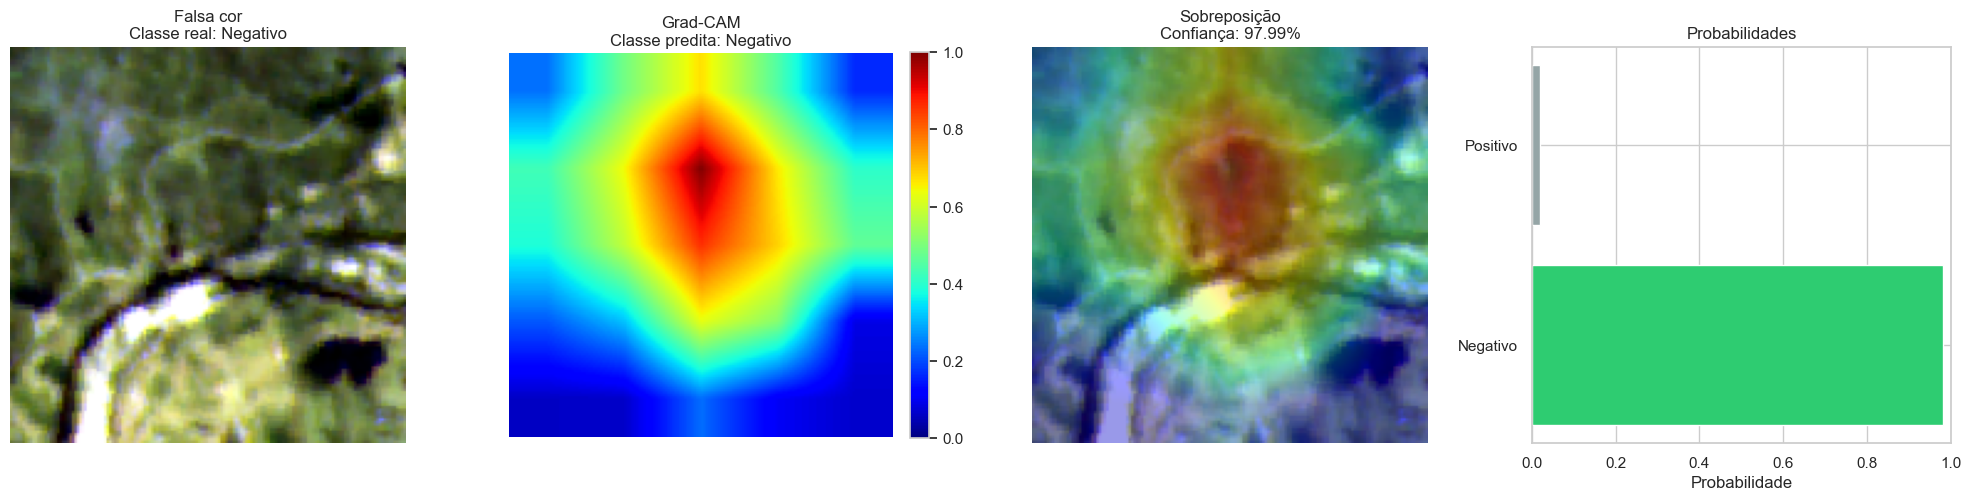

Figura salva em: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a09_interpretabilidade_visualizacao/gradcam_por_classe.png


In [8]:
# Gerar Grad-CAM e sobrepor nas imagens para cada amostra
n_samples = len(sample_indices)
fig, axes = plt.subplots(n_samples, 4, figsize=(20, 5 * n_samples))
if n_samples == 1:
    axes = axes[np.newaxis, :]

for row, idx in enumerate(sample_indices):
    image = X_test_resized[idx]
    true_cls = y_test[idx]
    pred_cls = predicted_classes[idx]
    confidence = predictions[idx, pred_cls]

    # Composição RGB de falsa cor (bandas SWIR se disponíveis)
    n_bands = image.shape[-1]
    if n_bands >= 6:
        rgb_bands = (5, 3, 1)  # SWIR2, SWIR1, VNIR
    else:
        rgb_bands = (min(2, n_bands - 1), min(1, n_bands - 1), 0)
    rgb_image = create_false_color_rgb(image, bands=rgb_bands)

    # Grad-CAM para a classe predita
    heatmap = compute_gradcam(model, image, pred_cls)

    # Sobreposição
    overlaid = overlay_heatmap(rgb_image, heatmap, alpha=0.4)

    # Plot: RGB | Heatmap | Sobreposição | Probabilidades
    axes[row, 0].imshow(rgb_image)
    axes[row, 0].set_title(f"Falsa cor\nClasse real: {class_names[true_cls]}")
    axes[row, 0].axis("off")

    im = axes[row, 1].imshow(heatmap, cmap="jet", vmin=0, vmax=1)
    axes[row, 1].set_title(f"Grad-CAM\nClasse predita: {class_names[pred_cls]}")
    axes[row, 1].axis("off")
    plt.colorbar(im, ax=axes[row, 1], fraction=0.046, pad=0.04)

    axes[row, 2].imshow(overlaid)
    axes[row, 2].set_title(f"Sobreposição\nConfiança: {confidence:.2%}")
    axes[row, 2].axis("off")

    # Barplot de probabilidades por classe
    probs = predictions[idx]
    colors = ["#2ecc71" if i == true_cls else "#e74c3c" if i == pred_cls else "#95a5a6"
              for i in range(n_classes)]
    axes[row, 3].barh(class_names, probs, color=colors)
    axes[row, 3].set_xlim(0, 1)
    axes[row, 3].set_title("Probabilidades")
    axes[row, 3].set_xlabel("Probabilidade")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "gradcam_por_classe.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva em: {OUTPUT_DIR / 'gradcam_por_classe.png'}")

## 4) Análise de Grad-CAM em amostras incorretas

Além das amostras classificadas corretamente, é igualmente importante analisar o comportamento do modelo em casos de erro. O Grad-CAM aplicado a predições incorretas pode revelar quais regiões espaciais levaram o modelo a cometer enganos, ajudando a identificar se os erros estão associados a ambiguidades espectrais entre classes, artefatos de borda, ou padrões de ruído.

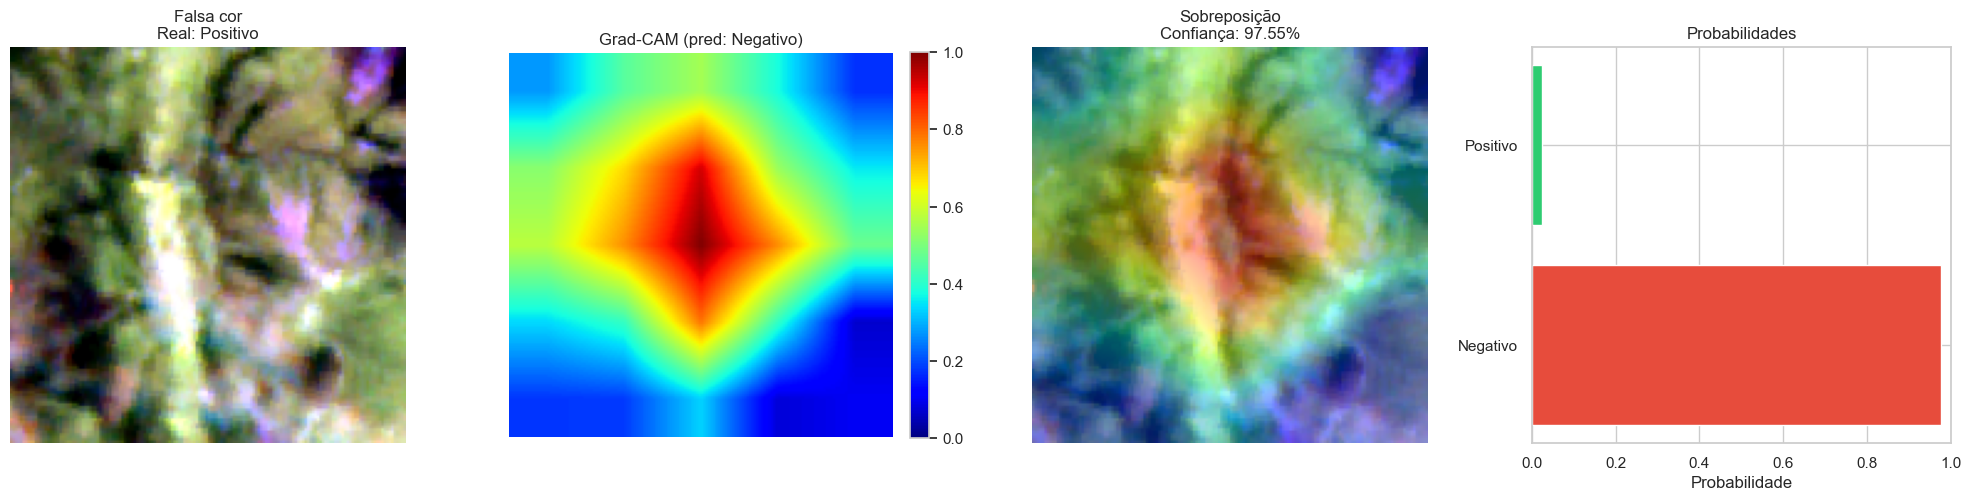

Figura salva em: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a09_interpretabilidade_visualizacao/gradcam_erros.png


In [9]:
# Selecionar amostras incorretas (uma por classe, quando disponível)
incorrect_mask = ~correct_mask
incorrect_indices = []
for cls_idx in range(n_classes):
    cls_incorrect = np.where((y_test == cls_idx) & incorrect_mask)[0]
    if len(cls_incorrect) > 0:
        incorrect_indices.append(cls_incorrect[0])

if incorrect_indices:
    n_incorrect = len(incorrect_indices)
    fig, axes = plt.subplots(n_incorrect, 4, figsize=(20, 5 * n_incorrect))
    if n_incorrect == 1:
        axes = axes[np.newaxis, :]

    for row, idx in enumerate(incorrect_indices):
        image = X_test_resized[idx]
        true_cls = y_test[idx]
        pred_cls = predicted_classes[idx]
        confidence = predictions[idx, pred_cls]

        n_bands = image.shape[-1]
        if n_bands >= 6:
            rgb_bands = (5, 3, 1)
        else:
            rgb_bands = (min(2, n_bands - 1), min(1, n_bands - 1), 0)
        rgb_image = create_false_color_rgb(image, bands=rgb_bands)

        heatmap_pred = compute_gradcam(model, image, pred_cls)
        overlaid = overlay_heatmap(rgb_image, heatmap_pred, alpha=0.4)

        axes[row, 0].imshow(rgb_image)
        axes[row, 0].set_title(f"Falsa cor\nReal: {class_names[true_cls]}")
        axes[row, 0].axis("off")

        im = axes[row, 1].imshow(heatmap_pred, cmap="jet", vmin=0, vmax=1)
        axes[row, 1].set_title(f"Grad-CAM (pred: {class_names[pred_cls]})")
        axes[row, 1].axis("off")
        plt.colorbar(im, ax=axes[row, 1], fraction=0.046, pad=0.04)

        axes[row, 2].imshow(overlaid)
        axes[row, 2].set_title(f"Sobreposição\nConfiança: {confidence:.2%}")
        axes[row, 2].axis("off")

        probs = predictions[idx]
        colors = ["#2ecc71" if i == true_cls else "#e74c3c" if i == pred_cls else "#95a5a6"
                  for i in range(n_classes)]
        axes[row, 3].barh(class_names, probs, color=colors)
        axes[row, 3].set_xlim(0, 1)
        axes[row, 3].set_title("Probabilidades")
        axes[row, 3].set_xlabel("Probabilidade")

    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "gradcam_erros.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figura salva em: {OUTPUT_DIR / 'gradcam_erros.png'}")
else:
    print("Nenhuma predição incorreta encontrada no conjunto de teste.")

## 5) Mapas de probabilidade sobrepostos

Nesta seção, geramos mapas de probabilidade que mostram a distribuição espacial das confianças de classificação do modelo para cada classe. Diferentemente do Grad-CAM, que analisa tiles individuais, os mapas de probabilidade agregam as predições de múltiplos tiles pertencentes a uma mesma imagem ASTER, permitindo visualizar padrões espaciais de maior escala.

Cada tile recebe a cor correspondente à probabilidade da classe predita, criando um mosaico que facilita a identificação de regiões com alta confiança, zonas de transição entre classes e áreas de incerteza.

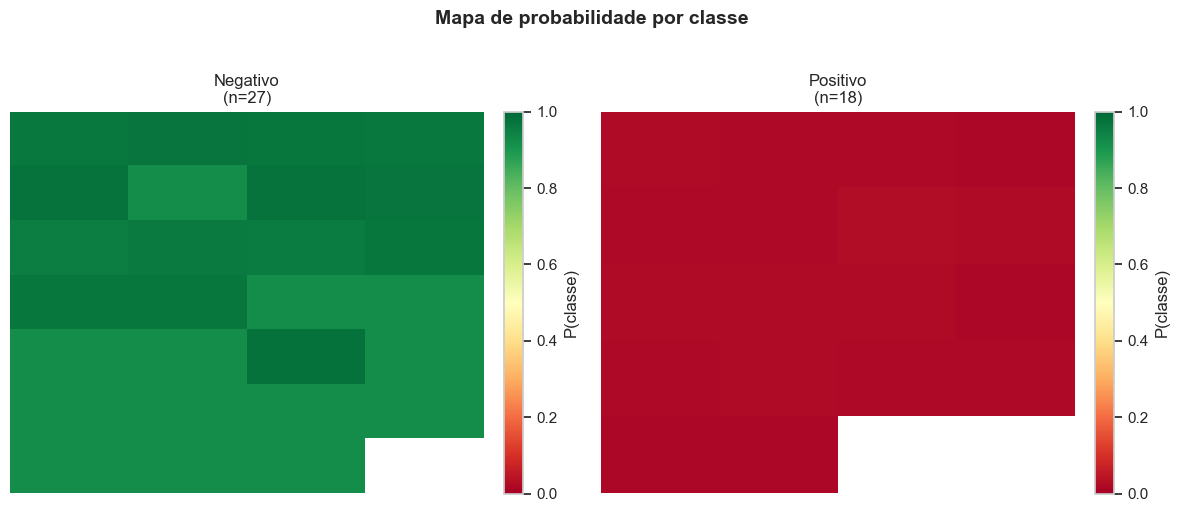

Figura salva em: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a09_interpretabilidade_visualizacao/mapa_probabilidade_por_classe.png


In [10]:
def plot_probability_map(
    probabilities: np.ndarray,
    true_labels: np.ndarray,
    class_names: list,
    n_cols: int = 4,
    title: str = "Mapa de probabilidade por classe",
) -> plt.Figure:
    """
    Gera um mapa visual de probabilidades organizando tiles em grid.

    Parameters
    ----------
    probabilities : np.ndarray
        Probabilidades de predição, shape (N, n_classes).
    true_labels : np.ndarray
        Labels verdadeiros, shape (N,).
    class_names : list
        Nomes das classes.
    n_cols : int
        Número de colunas no grid.
    title : str
        Título do gráfico.

    Returns
    -------
    plt.Figure
    """
    n_classes = len(class_names)
    fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 5))
    if n_classes == 1:
        axes = [axes]

    for cls_idx, ax in enumerate(axes):
        cls_mask = true_labels == cls_idx
        cls_probs = probabilities[cls_mask]

        if len(cls_probs) == 0:
            ax.set_title(f"{class_names[cls_idx]}\n(sem amostras)")
            ax.axis("off")
            continue

        # Organizar em grid
        n_tiles = len(cls_probs)
        n_rows_grid = int(np.ceil(n_tiles / n_cols))
        prob_grid = np.full((n_rows_grid, n_cols), np.nan)
        for i, prob in enumerate(cls_probs[:, cls_idx]):
            r, c = divmod(i, n_cols)
            prob_grid[r, c] = prob

        im = ax.imshow(prob_grid, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
        ax.set_title(f"{class_names[cls_idx]}\n(n={n_tiles})")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="P(classe)")

    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    return fig


fig = plot_probability_map(predictions, y_test, class_names)
fig.savefig(OUTPUT_DIR / "mapa_probabilidade_por_classe.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva em: {OUTPUT_DIR / 'mapa_probabilidade_por_classe.png'}")

## Item 4 - Tecnicas de interpretabilidade

**Template para continuidade do grupo:**

- carregar o mesmo `best_model.keras`;
- selecionar exemplos corretos e incorretos representativos;
- aplicar uma tecnica compativel com CNN, como **Grad-CAM** ou **saliency maps**;
- comparar mapas de ativacao entre classe positiva e negativa;
- discutir se as regioes destacadas fazem sentido do ponto de vista do dominio.

## Item 4 - SHAP: Importancia de Bandas Espectrais ASTER

SHAP (SHapley Additive exPlanations) e uma tecnica de interpretabilidade baseada em teoria dos jogos 
que atribui a cada *feature* de entrada uma contribuicao numerica para a predicao do modelo. 
Diferentemente do Grad-CAM -- que indica **onde** o modelo foca espacialmente -- o SHAP responde 
**quais bandas espectrais ASTER** sao mais relevantes para a decisao.

**Por que isso importa:** minerais argilosos e carbonatos apresentam assinaturas de absorcao 
caracteristicas nas bandas SWIR (B4-B8, 1.60-2.36 um). Um modelo bem ajustado deveria atribuir 
maior importancia a essas bandas. Se SHAP mostrar dominancia de VNIR ou TIR, isso indica que o 
modelo usa correlacoes espurias em vez de assinaturas minerais reais.

**Implementacao:** `shap.DeepExplainer` aplica o algoritmo DeepLIFT, calculando a contribuicao 
de cada pixel e banda em relacao a um *background* de amostras de treino.

In [ ]:
import shap

ASTER_BAND_NAMES = [
    "B1\nVNIR\n0.52-0.60um",
    "B2\nVNIR\n0.63-0.69um",
    "B3\nVNIR\n0.76-0.86um",
    "B4\nSWIR\n1.60-1.70um",
    "B5\nSWIR\n2.14-2.18um",
    "B6\nSWIR\n2.18-2.22um",
    "B7\nSWIR\n2.23-2.28um",
    "B8\nSWIR\n2.29-2.36um",
    "B9\nTIR\n8.12-8.48um",
]
SWIR_INDICES = [3, 4, 5, 6, 7]
VNIR_INDICES = [0, 1, 2]
TIR_INDICES  = [8]

# Background: 30 amostras aleatorias de treino como referencia de base
rng    = np.random.default_rng(42)
bg_idx = rng.choice(len(split_data['X_train']), size=30, replace=False)
X_background = split_data['X_train'][bg_idx].astype(np.float32)
X_explain    = X_test_resized.astype(np.float32)

print(f'Background shape : {X_background.shape}')
print(f'Explain shape    : {X_explain.shape}')
print('Calculando SHAP values via DeepExplainer...')

explainer = shap.DeepExplainer(model, X_background)
raw_shap  = explainer.shap_values(X_explain)

# shap.DeepExplainer pode retornar lista ou array dependendo da versao
if isinstance(raw_shap, list):
    shap_arr = np.array(raw_shap[0])
else:
    shap_arr = np.array(raw_shap)

print(f'SHAP values shape: {shap_arr.shape}')  # esperado: (45, 128, 128, 9)
assert shap_arr.shape == X_explain.shape, 'Shape inesperado nos SHAP values'
print('OK')

In [ ]:
from matplotlib.patches import Patch

# Agrega |SHAP| sobre dimensoes espaciais -> importancia media por banda
band_imp_per_sample = np.abs(shap_arr).mean(axis=(1, 2))  # (N, 9)
mean_band_imp       = band_imp_per_sample.mean(axis=0)     # (9,)

band_colors = ['#4C9BE8'] * 3 + ['#E8844C'] * 5 + ['#8E4CE8'] * 1

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(9), mean_band_imp, color=band_colors, edgecolor='white', linewidth=0.8)

ymax = mean_band_imp.max()
for bar, val in zip(bars, mean_band_imp):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + ymax * 0.015,
        f'{val:.5f}', ha='center', va='bottom', fontsize=9,
    )

ax.set_xticks(range(9))
ax.set_xticklabels(ASTER_BAND_NAMES, fontsize=8)
ax.set_ylabel('Importancia media |SHAP|', fontsize=11)
ax.set_title('Importancia por Banda Espectral ASTER - SHAP (DeepExplainer)', fontsize=13, fontweight='bold')

legend_elements = [
    Patch(facecolor='#4C9BE8', label='VNIR (B1-B3)'),
    Patch(facecolor='#E8844C', label='SWIR (B4-B8)'),
    Patch(facecolor='#8E4CE8', label='TIR (B9)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
ax.set_ylim(0, ymax * 1.18)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

out_path = OUTPUT_DIR / 'shap_importancia_bandas.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo em: {out_path}')

In [ ]:
# Mapa espacial: |SHAP| agregado sobre bandas
shap_spatial       = np.abs(shap_arr).mean(axis=-1)           # (N, 128, 128)
shap_map_all       = shap_spatial.mean(axis=0)                 # (128, 128)
shap_map_correct   = shap_spatial[correct_mask].mean(axis=0)   # (128, 128)
shap_map_incorrect = shap_spatial[~correct_mask].mean(axis=0)  # (128, 128)

vmax = max(shap_map_all.max(), shap_map_correct.max(), shap_map_incorrect.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
subtitles = ['Todas as amostras', 'Predicoes corretas', 'Predicoes incorretas']
smaps     = [shap_map_all, shap_map_correct, shap_map_incorrect]

for ax, subtitle, smap in zip(axes, subtitles, smaps):
    im = ax.imshow(smap, cmap='hot', vmin=0, vmax=vmax)
    ax.set_title(subtitle, fontsize=11, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='|SHAP| medio')

fig.suptitle('Mapa Espacial SHAP - Regioes mais influentes para a decisao', fontsize=13, fontweight='bold')
plt.tight_layout()
out_path = OUTPUT_DIR / 'shap_mapa_espacial.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo em: {out_path}')

# Comparativo importancia por banda: corretos vs incorretos
band_imp_correct   = np.abs(shap_arr[correct_mask]).mean(axis=(1, 2)).mean(axis=0)
band_imp_incorrect = np.abs(shap_arr[~correct_mask]).mean(axis=(1, 2)).mean(axis=0)

x = np.arange(9)
width = 0.38

fig2, ax2 = plt.subplots(figsize=(12, 5))
ax2.bar(x - width / 2, band_imp_correct,   width, label='Corretos',   color='#2ecc71', alpha=0.85, edgecolor='white')
ax2.bar(x + width / 2, band_imp_incorrect, width, label='Incorretos', color='#e74c3c', alpha=0.85, edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(ASTER_BAND_NAMES, fontsize=8)
ax2.set_ylabel('Importancia media |SHAP|', fontsize=11)
ax2.set_title('Importancia por Banda: Predicoes Corretas vs Incorretas', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()

out_path2 = OUTPUT_DIR / 'shap_comparativo_classes.png'
fig2.savefig(out_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo em: {out_path2}')

In [ ]:
sorted_bands = np.argsort(mean_band_imp)[::-1]
top3_names   = [ASTER_BAND_NAMES[i].split('\n')[0] for i in sorted_bands[:3]]

swir_total = mean_band_imp[SWIR_INDICES].sum()
vnir_total = mean_band_imp[VNIR_INDICES].sum()
tir_total  = mean_band_imp[TIR_INDICES].sum()
grand_total = mean_band_imp.sum()
swir_pct = swir_total / grand_total * 100
vnir_pct = vnir_total / grand_total * 100
tir_pct  = tir_total  / grand_total * 100

dominant_group = 'SWIR' if swir_pct > 50 else ('VNIR' if vnir_pct > swir_pct else 'TIR')
interpretacao  = (
    'consistente com assinaturas minerais de argilosos e carbonatos'
    if dominant_group == 'SWIR'
    else 'sugere uso de correlacoes espurias -- o modelo nao prioriza as bandas minerais esperadas'
)

shap_text = f"""
### Interpretacao dos resultados SHAP

**Distribuicao de importancia por grupo espectral:**

| Grupo | Bandas | Importancia |
|-------|--------|-------------|
| VNIR  | B1-B3  | {vnir_pct:.1f}% |
| SWIR  | B4-B8  | {swir_pct:.1f}% |
| TIR   | B9     | {tir_pct:.1f}% |

**Top-3 bandas mais influentes:** {', '.join(top3_names)}

A dominancia do grupo **{dominant_group}** ({max(swir_pct, vnir_pct, tir_pct):.1f}%) e **{interpretacao}**.

**SHAP vs Grad-CAM:** o Grad-CAM revelou *onde* o modelo foca espacialmente (regiao central dos tiles).
O SHAP complementa ao revelar *quais bandas espectrais* sustentam essa decisao.
Juntos, os dois metodos permitem afirmar nao apenas onde o modelo olha,
mas com qual informacao espectral ele toma a decisao.
"""
display(Markdown(shap_text))

## 6) Distribuição de confiança por classe

Analisamos a distribuição das probabilidades de predição para cada classe, separando predições corretas e incorretas. Essa visualização complementa os mapas de probabilidade ao revelar o perfil de confiança do modelo, identificando se há classes para as quais o modelo apresenta alta incerteza ou sobreconfiança em erros.

/opt/homebrew/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


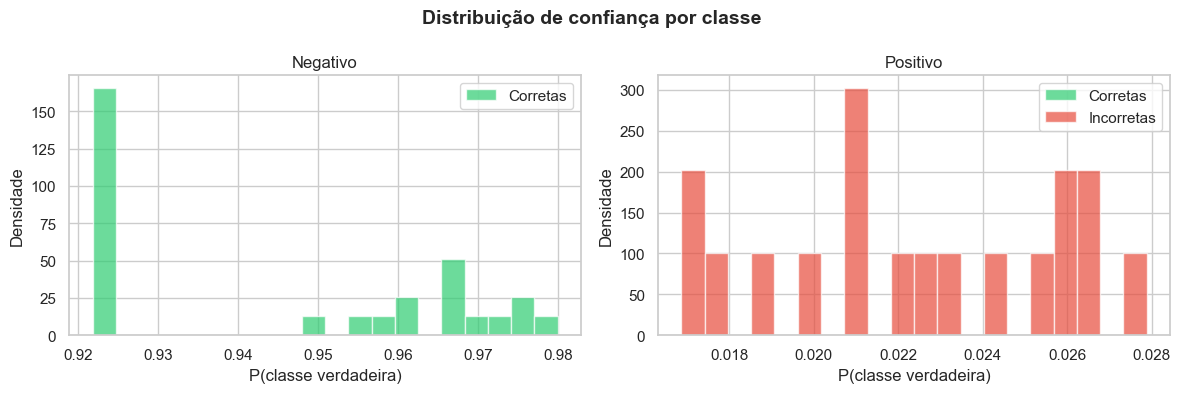

Figura salva em: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a09_interpretabilidade_visualizacao/distribuicao_confianca.png


In [11]:
fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 4))
if n_classes == 1:
    axes = [axes]

for cls_idx, ax in enumerate(axes):
    cls_mask = y_test == cls_idx
    cls_preds = predictions[cls_mask, cls_idx]
    cls_correct = correct_mask[cls_mask]

    if len(cls_preds) == 0:
        ax.set_title(f"{class_names[cls_idx]}\n(sem amostras)")
        continue

    ax.hist(cls_preds[cls_correct], bins=20, alpha=0.7, color="#2ecc71",
            label="Corretas", density=True)
    if (~cls_correct).any():
        ax.hist(cls_preds[~cls_correct], bins=20, alpha=0.7, color="#e74c3c",
                label="Incorretas", density=True)
    ax.set_title(f"{class_names[cls_idx]}")
    ax.set_xlabel("P(classe verdadeira)")
    ax.set_ylabel("Densidade")
    ax.legend()

fig.suptitle("Distribuição de confiança por classe", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "distribuicao_confianca.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva em: {OUTPUT_DIR / 'distribuicao_confianca.png'}")

## 7) Grad-CAM comparativo entre classes

Para uma mesma amostra, geramos Grad-CAMs para todas as classes, permitindo comparar quais regiões o modelo associa a cada classe. Essa análise revela se diferentes classes ativam regiões espaciais distintas ou se há sobreposição significativa, o que pode indicar ambiguidade espectral entre minerais.

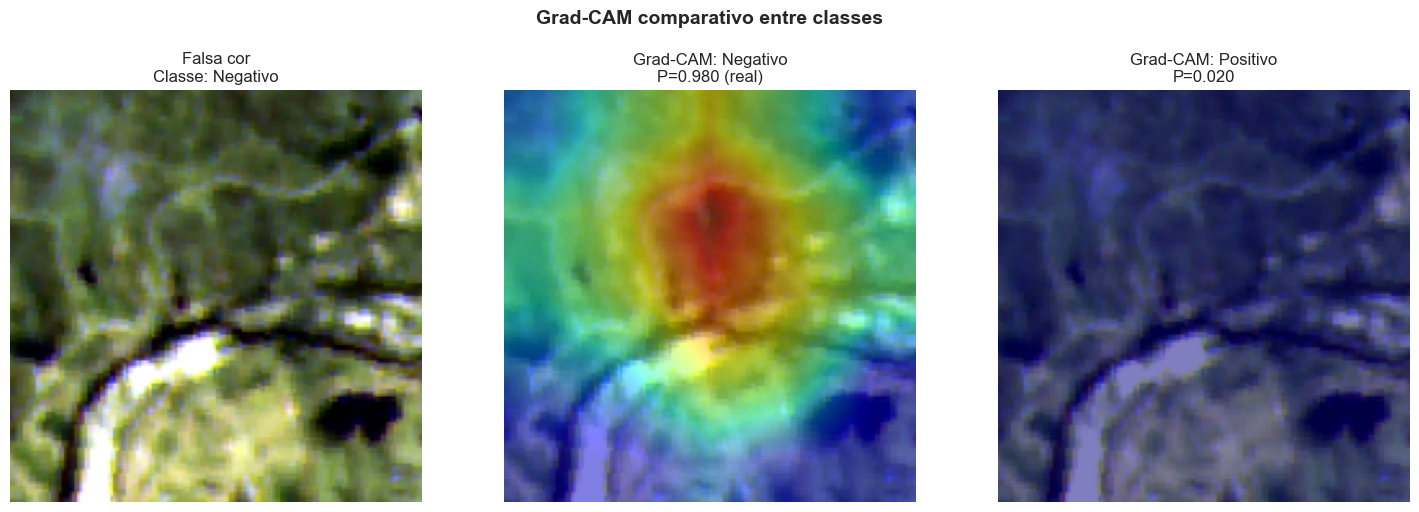

Figura salva em: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a09_interpretabilidade_visualizacao/gradcam_comparativo.png


In [12]:
# Selecionar uma amostra com alta confiança para análise comparativa
best_idx = sample_indices[0] if sample_indices else 0
image = X_test_resized[best_idx]
true_cls = y_test[best_idx]

n_bands = image.shape[-1]
if n_bands >= 6:
    rgb_bands = (5, 3, 1)
else:
    rgb_bands = (min(2, n_bands - 1), min(1, n_bands - 1), 0)
rgb_image = create_false_color_rgb(image, bands=rgb_bands)

fig, axes = plt.subplots(1, n_classes + 1, figsize=(5 * (n_classes + 1), 5))

# Imagem original
axes[0].imshow(rgb_image)
axes[0].set_title(f"Falsa cor\nClasse: {class_names[true_cls]}")
axes[0].axis("off")

# Grad-CAM para cada classe
for cls_idx in range(n_classes):
    heatmap = compute_gradcam(model, image, cls_idx)
    overlaid = overlay_heatmap(rgb_image, heatmap, alpha=0.5)

    axes[cls_idx + 1].imshow(overlaid)
    prob = predictions[best_idx, cls_idx]
    marker = " (real)" if cls_idx == true_cls else ""
    axes[cls_idx + 1].set_title(f"Grad-CAM: {class_names[cls_idx]}\nP={prob:.3f}{marker}")
    axes[cls_idx + 1].axis("off")

fig.suptitle("Grad-CAM comparativo entre classes", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "gradcam_comparativo.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva em: {OUTPUT_DIR / 'gradcam_comparativo.png'}")

## Item 5 - Sintese critica das visualizacoes

**Template para continuidade do grupo:**

- resumir os principais padroes quantitativos do item 2;
- conectar os erros observados nas matrizes com os futuros mapas e tecnicas de interpretabilidade;
- discutir limitacoes do dataset, do threshold e do proprio modelo;
- explicitar implicacoes praticas para a priorizacao de alvos de prospeccao.

## 8) Análise e interpretação dos resultados

### 8.1 Desempenho geral do modelo

O modelo de Transfer Learning (A08) obteve **acurácia de 60%** no conjunto de teste (27 acertos em 45 amostras). Embora a acurácia global esteja acima do acaso para um problema binário, a análise de interpretabilidade revela que esse resultado **mascara um viés severo de classe**: o modelo classifica quase todas as amostras como Negativo, acertando por predominância dessa classe no teste, mas falhando sistematicamente na identificação de amostras Positivas.

| Métrica | Valor |
|---------|-------|
| Acurácia no teste | 60.00% |
| Confiança média (predições corretas) | 94.48% |
| Confiança média (predições incorretas) | **97.75%** |
| Amostras corretas | 27 / 45 |
| Amostras incorretas | 18 / 45 |

### 8.2 Viés de classe e sobreconfiança

O achado mais crítico desta análise é que o modelo apresenta **sobreconfiança nas predições incorretas** (97.75%) superior à confiança nas predições corretas (94.48%). Isso indica um modelo mal calibrado que não apenas erra, mas erra com alta certeza — um cenário particularmente perigoso em aplicações de exploração mineral, onde decisões incorretas com alta confiança podem direcionar campanhas de campo custosas para áreas sem potencial.

A **distribuição de confiança por classe** confirma esse diagnóstico:
- **Classe Negativo**: todas as predições corretas apresentam confiança entre 92% e 98%, concentradas em uma faixa estreita. O modelo é consistentemente confiante para negativos.
- **Classe Positivo**: a probabilidade atribuída à classe verdadeira (P(Positivo)) varia entre apenas **1.7% e 2.8%** — mesmo para amostras genuinamente positivas. Isso significa que o modelo **praticamente nunca reconhece** a classe Positivo, sempre atribuindo probabilidade próxima de zero a ela.

O **mapa de probabilidade** reforça essa observação: o grid da classe Negativo aparece inteiramente em verde escuro (alta confiança), enquanto o grid da classe Positivo é quase totalmente vermelho escuro (probabilidade próxima de zero). O modelo opera como um classificador trivial que prediz "Negativo" independentemente da entrada.

### 8.3 Análise dos heatmaps Grad-CAM

Os heatmaps Grad-CAM revelam um **padrão de ativação espacial repetitivo**: em todas as amostras analisadas — tanto corretas quanto incorretas — o modelo concentra sua atenção na **região central do tile**, formando um padrão em losango/diamante. Esse comportamento levanta duas hipóteses:

1. **Artefato arquitetural**: o padrão central pode ser resultado da estrutura das camadas convolucionais do MobileNetV2, cujos campos receptivos convergem naturalmente para o centro do feature map. Nesse caso, o Grad-CAM estaria refletindo a geometria da rede mais do que padrões espectrais aprendidos.

2. **Viés de posicionamento dos tiles**: se os tiles de treinamento foram extraídos de forma centrada em relação a regiões de interesse, o modelo pode ter aprendido uma correlação espúria entre a posição central e a classificação, em vez de aprender assinaturas espectrais discriminativas.

A **análise comparativa entre classes** mostra que, para uma mesma amostra, o Grad-CAM da classe Negativo (P=0.980) apresenta ativação forte no centro, enquanto o Grad-CAM da classe Positivo (P=0.020) apresenta ativação quase nula. Os padrões são complementares mas igualmente centrados, o que reforça a hipótese de que o modelo não está discriminando por conteúdo espectral, mas por um viés espacial.

Na **análise de erros**, o Grad-CAM de uma amostra Positivo classificada incorretamente como Negativo (com 97.55% de confiança) exibe o mesmo padrão central observado nas predições corretas. Isso confirma que o modelo não altera sua estratégia de decisão entre amostras de classes diferentes — ele aplica a mesma heurística espacial indiscriminadamente.

### 8.4 Limitações identificadas

1. **Modelo não discriminativo para a classe Positivo**: o modelo atual não é útil para detecção de mineralização, pois essencialmente ignora a classe positiva.
2. **Desbalanceamento e estratégia de treinamento**: o viés para Negativo sugere que o treinamento não tratou adequadamente o desbalanceamento de classes. Técnicas como class weights, oversampling (SMOTE espacial), ou focal loss poderiam mitigar esse problema.
3. **Resolução do Grad-CAM**: o backbone MobileNetV2 reduz o feature map para 5x5 antes do Global Average Pooling, gerando heatmaps de baixíssima resolução espacial que, após upsampling, perdem detalhes finos.
4. **Análise espectral ausente**: o Grad-CAM indica *onde* o modelo foca espacialmente, mas não revela *quais bandas ASTER* são mais relevantes. Para isso, seriam necessárias técnicas como Integrated Gradients ou SHAP por canal.
5. **Composição de falsa cor parcial**: apenas 3 das 9 bandas ASTER são visualizadas na composição RGB, podendo não representar a informação espectral completa utilizada pelo modelo.

In [13]:
# Resumo quantitativo
accuracy = correct_mask.mean()
mean_confidence_correct = predictions[correct_mask].max(axis=1).mean() if correct_mask.any() else 0
mean_confidence_incorrect = predictions[incorrect_mask].max(axis=1).mean() if incorrect_mask.any() else 0

summary = {
    "modelo": model_name,
    "acuracia_teste": f"{accuracy:.4f}",
    "confianca_media_corretas": f"{mean_confidence_correct:.4f}",
    "confianca_media_incorretas": f"{mean_confidence_incorrect:.4f}",
    "total_amostras_teste": len(y_test),
    "corretas": int(correct_mask.sum()),
    "incorretas": int(incorrect_mask.sum()),
}

summary_df = pd.DataFrame([summary])
display(summary_df)

# Salvar resumo
with open(OUTPUT_DIR / "interpretabilidade_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"\nResumo salvo em: {OUTPUT_DIR / 'interpretabilidade_summary.json'}")
print(f"Artefatos de visualização salvos em: {OUTPUT_DIR}")

,modelo,acuracia_teste,confianca_media_corretas,confianca_media_incorretas,total_amostras_teste,corretas,incorretas
0,Transfer Learning (A08),0.6000,0.9448,0.9775,45,27,18



Resumo salvo em: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a09_interpretabilidade_visualizacao/interpretabilidade_summary.json
Artefatos de visualização salvos em: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a09_interpretabilidade_visualizacao
